# 01 - Data Merging: PISA 2022 Process Data Analysis

## Purpose
This notebook merges three PISA 2022 international data files into a single 
analysis-ready dataset for downstream machine learning modeling.

## Data Sources
- **CY08MSP_STU_COG.SAV** (3.5 GB): Cognitive assessment with process data 
  (mathematics CM/DM columns) and 10 plausible values (PV1MATH - PV10MATH)
- **CY08MSP_STU_QQQ.SAV** (2 GB): Student background questionnaire 
  (ESCS, gender, parental education, self-efficacy, anxiety, etc.)
- **CY08MSP_STU_TIM.SAV** (633 MB): Timing data (only EFFORTT retained as 
  effort/motivation indicator)

## Output
- `data/analysis/pisa2022_ml_dataset.parquet`: Merged dataset with student-level 
  mathematics achievement, process features, and contextual variables.

## Strategy
Given the size of COG.SAV (3.5 GB), we use chunked reading via pyreadstat to 
avoid memory overflow on Apple Silicon. Non-mathematics process columns and 
questionnaire timing columns are excluded early to reduce memory footprint.

In [71]:
# Imports and environment check

# Standard libraries for data handling, file I/O, and memory monitoring.
# pyreadstat is used for reading SPSS .SAV files with metadata preservation.

import os
import gc  # Garbage collector for manual memory release after large reads
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyreadstat  # SPSS .SAV reader with chunked reading support
import psutil  # For monitoring memory usage during large file operations

warnings.filterwarnings("ignore")

# Display settings for pandas: show more columns and wider output
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

# Reproducibility: all stochastic operations downstream use this seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Environment check: confirm Python version and key package versions
print("Environment check")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"pyreadstat   : {pyreadstat.__version__}")
print(f"Available RAM: {psutil.virtual_memory().available / 1e9:.2f} GB")
print(f"Total RAM    : {psutil.virtual_memory().total / 1e9:.2f} GB")
print(f"Random seed  : {RANDOM_SEED}")

Environment check
pandas       : 3.0.2
numpy        : 2.4.4
pyreadstat   : 1.3.4
Available RAM: 4.71 GB
Total RAM    : 17.18 GB
Random seed  : 42


In [72]:
# Define project paths

# Using pathlib for cross-platform path handling. Paths are defined relative
# to the project root so the notebook remains portable.

# Project root: two levels up from notebooks/process_data/
PROJECT_ROOT = Path.home() / "Desktop" / "PISA-Process-Data-Analysis"

# Input directories
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ANALYSIS_DIR = PROJECT_ROOT / "data" / "analysis"

# Ensure output directories exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Input file paths
COG_PATH = RAW_DIR / "CY08MSP_STU_COG.SAV"
QQQ_PATH = RAW_DIR / "CY08MSP_STU_QQQ.SAV"
TIM_PATH = RAW_DIR / "CY08MSP_STU_TIM.SAV"

# Output path
OUTPUT_PATH = ANALYSIS_DIR / "pisa2022_ml_dataset.parquet"

# Verify input files exist and report their sizes
print("Input file check")
for name, path in [("COG", COG_PATH), ("QQQ", QQQ_PATH), ("TIM", TIM_PATH)]:
    if path.exists():
        size_gb = path.stat().st_size / 1e9
        print(f"[OK]      {name}: {path.name}  ({size_gb:.2f} GB)")
    else:
        print(f"[MISSING] {name}: {path}")

print(f"\nOutput will be saved to: {OUTPUT_PATH}")

Input file check
[OK]      COG: CY08MSP_STU_COG.SAV  (3.73 GB)
[OK]      QQQ: CY08MSP_STU_QQQ.SAV  (2.10 GB)
[OK]      TIM: CY08MSP_STU_TIM.SAV  (0.66 GB)

Output will be saved to: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_ml_dataset.parquet


In [73]:
# Read COG metadata only (no data) to inspect column structure

# pyreadstat's metadataonly=True reads only the file header without loading
# the actual data. This is critical for a 3.73 GB file: we first identify
# which columns we need, then read only those columns in the next step.
# This approach reduces memory usage dramatically.

print("Reading COG metadata (header only, no data)...")
start = time.time()

# metadataonly=True returns an empty DataFrame but a full metadata object
_, cog_meta = pyreadstat.read_sav(
    str(COG_PATH),
    metadataonly=True
)

elapsed = time.time() - start
print(f"Metadata read in {elapsed:.1f} seconds")
print(f"Total columns in COG: {len(cog_meta.column_names)}")
print(f"Total rows in COG   : {cog_meta.number_rows:,}")

Reading COG metadata (header only, no data)...
Metadata read in 0.3 seconds
Total columns in COG: 5023
Total rows in COG   : 613,744


In [74]:
# Categorize COG columns: distinguish CM (standard/core items) from CMA items
#
# PISA 2022 uses a Multi-Stage Adaptive Testing (MSAT) design for mathematics
# (OECD, 2024, Technical Report, Chapter 2). Two item prefix families appear
# in the COG file:
#
#   CM*  : Standard/core mathematics items seen by students according to
#          their booklet assignment.
#   CMA* : Items whose role (adaptive routing, anchor items, etc.) requires
#          verification against the PISA 2022 Technical Report and Codebook.
#          We retain them at the integration stage and document their
#          empirical characteristics in downstream cells so a principled
#          inclusion/exclusion decision can be made in NB02.
#
# Both families share the same process-data suffix structure:
#   TT : Total time on item (ms)
#   A  : Number of actions
#   V  : Number of visits
#   F  : First-visit duration (ms)
#   VS : Visit sequence (encoded)

import re

all_cols = cog_meta.column_names

# Helper: extract trailing alphabetic suffix from a column name
def get_suffix(col):
    match = re.search(r'[A-Z]+$', col)
    return match.group() if match else ""

# ID columns for joining with QQQ and TIM
id_cols = [c for c in all_cols if c in ("CNTSTUID", "CNT", "CNTSCHID")]

# Process-data suffixes we want to keep
process_suffixes = {"TT", "A", "V", "F", "VS"}

# CM vs CMA disambiguation:
#   - CMA items start with "CMA"
#   - CM (core) items start with "CM" but NOT "CMA"
# Regex prefixes applied below reflect this distinction.
cm_core_pattern = re.compile(r'^CM(?!A)')   # CM but not CMA
cma_pattern = re.compile(r'^CMA')

cm_core_process_cols = [
    c for c in all_cols
    if cm_core_pattern.match(c) and get_suffix(c) in process_suffixes
]

cma_process_cols = [
    c for c in all_cols
    if cma_pattern.match(c) and get_suffix(c) in process_suffixes
]

# Union: all mathematics process columns to read
cog_cols_to_read = id_cols + cm_core_process_cols + cma_process_cols

# Extract unique item IDs (e.g., "CM033Q01" or "CMA135Q04") for reporting
def get_item_id(col):
    """Strip trailing suffix to get the base item identifier."""
    for suf in sorted(process_suffixes, key=len, reverse=True):
        if col.endswith(suf):
            return col[:-len(suf)]
    return col

cm_core_items = sorted({get_item_id(c) for c in cm_core_process_cols})
cma_items = sorted({get_item_id(c) for c in cma_process_cols})

print("COG column selection summary:")
print(f"  ID columns        : {len(id_cols)} -> {id_cols}")
print(f"  CM (core) process columns : {len(cm_core_process_cols)}")
print(f"  CMA process columns       : {len(cma_process_cols)}")
print(f"  Total columns to read     : {len(cog_cols_to_read)}")
print(f"  Reduction: {len(cog_cols_to_read)}/{len(all_cols)} = "
      f"{100*len(cog_cols_to_read)/len(all_cols):.1f}%")

print(f"\nUnique math items:")
print(f"  CM (core) items : {len(cm_core_items)}")
print(f"  CMA items       : {len(cma_items)}")
print(f"  Total unique    : {len(cm_core_items) + len(cma_items)}")

print("\nCM (core) breakdown by suffix:")
for suf in sorted(process_suffixes):
    count = sum(1 for c in cm_core_process_cols if get_suffix(c) == suf)
    print(f"  {suf}: {count}")

print("\nCMA breakdown by suffix:")
for suf in sorted(process_suffixes):
    count = sum(1 for c in cma_process_cols if get_suffix(c) == suf)
    print(f"  {suf}: {count}")

print("\nExample CM (core) items (first 3):")
print(f"  {cm_core_items[:3]}")
print("Example CMA items (first 3):")
print(f"  {cma_items[:3]}")

COG column selection summary:
  ID columns        : 3 -> ['CNT', 'CNTSCHID', 'CNTSTUID']
  CM (core) process columns : 370
  CMA process columns       : 800
  Total columns to read     : 1173
  Reduction: 1173/5023 = 23.4%

Unique math items:
  CM (core) items : 74
  CMA items       : 160
  Total unique    : 234

CM (core) breakdown by suffix:
  A: 74
  F: 74
  TT: 74
  V: 74
  VS: 74

CMA breakdown by suffix:
  A: 160
  F: 160
  TT: 160
  V: 160
  VS: 160

Example CM (core) items (first 3):
  ['CM00GQ01', 'CM00KQ02', 'CM033Q01']
Example CMA items (first 3):
  ['CMA101Q01', 'CMA101Q02', 'CMA102Q01']


In [75]:
# Read QQQ and TIM metadata before column selection
#
# Previous version of this notebook referenced qqq_meta without defining it,
# causing a NameError. This cell resolves that by reading metadata from both
# QQQ and TIM files upfront, so that column existence can be verified before
# full reads are attempted.

print("Reading QQQ metadata...")
start = time.time()
_, qqq_meta = pyreadstat.read_sav(str(QQQ_PATH), metadataonly=True)
print(f"  QQQ metadata read in {time.time()-start:.1f} seconds")
print(f"  QQQ columns: {len(qqq_meta.column_names):,}")
print(f"  QQQ rows   : {qqq_meta.number_rows:,}")

print("\nReading TIM metadata...")
start = time.time()
_, tim_meta = pyreadstat.read_sav(str(TIM_PATH), metadataonly=True)
print(f"  TIM metadata read in {time.time()-start:.1f} seconds")
print(f"  TIM columns: {len(tim_meta.column_names):,}")
print(f"  TIM rows   : {tim_meta.number_rows:,}")

# Sanity check: all three files should have the same number of rows
print("\nRow count consistency check:")
print(f"  COG: {cog_meta.number_rows:,}")
print(f"  QQQ: {qqq_meta.number_rows:,}")
print(f"  TIM: {tim_meta.number_rows:,}")
assert cog_meta.number_rows == qqq_meta.number_rows == tim_meta.number_rows, \
    "Row count mismatch across PISA files — investigate before proceeding"
print("  All three files have matching row counts.")

Reading QQQ metadata...
  QQQ metadata read in 0.1 seconds
  QQQ columns: 1,278
  QQQ rows   : 613,744

Reading TIM metadata...
  TIM metadata read in 0.0 seconds
  TIM columns: 172
  TIM rows   : 613,744

Row count consistency check:
  COG: 613,744
  QQQ: 613,744
  TIM: 613,744
  All three files have matching row counts.


In [76]:
# Define columns to read from QQQ and TIM files
#
# QQQ: plausible values + contextual variables + sampling weight
# TIM: only EFFORTT retained as effort indicator
#
# W_FSTUWT (final student weight):
#   PISA's final student weight, required for population-representative
#   estimates. We include it in the integrated dataset so that NB03 can run
#   weighted vs unweighted sensitivity analyses. Our primary ML analysis
#   models individual-level behavioural patterns (not country-level
#   population parameters), but including the weight ensures full
#   transparency and enables replication of OECD-aligned analyses
#   (OECD, 2024, Technical Report, Chapter 8).
#
# HOMEPOS substitution for HEDRES:
#   HEDRES (Home Educational Resources) is not published in the PISA 2022
#   data release. HOMEPOS (Home Possessions index) is used as a broader
#   parent index that includes educational resources as one component.
#   This deviation is disclosed in the technical report.

qqq_id_cols = ["CNTSTUID"]
qqq_pv_cols = [f"PV{i}MATH" for i in range(1, 11)]
qqq_weight_cols = ["W_FSTUWT"]
qqq_context_cols = [
    "ESCS",
    "ST004D01T",
    "ST019AQ01T",
    "MISCED",
    "FISCED",
    "HOMEPOS",
    "ICTHOME",
    "MATHEFF",
    "ANXMAT",
    "BELONG",
]

qqq_cols_to_read = qqq_id_cols + qqq_pv_cols + qqq_weight_cols + qqq_context_cols
tim_cols_to_read = ["CNTSTUID", "EFFORTT"]

# Verify QQQ columns exist in the file
qqq_available = set(qqq_meta.column_names)
qqq_missing = [c for c in qqq_cols_to_read if c not in qqq_available]

if qqq_missing:
    print(f"WARNING: QQQ columns not found: {qqq_missing}")
    print("Proceeding, but these will be absent from the merged dataset.")
    # Drop missing columns from the read list
    qqq_cols_to_read = [c for c in qqq_cols_to_read if c in qqq_available]
else:
    print("All QQQ columns verified present in file.")

# Verify TIM columns exist
tim_available = set(tim_meta.column_names)
tim_missing = [c for c in tim_cols_to_read if c not in tim_available]
if tim_missing:
    print(f"WARNING: TIM columns not found: {tim_missing}")
else:
    print("All TIM columns verified present in file.")

print(f"\nQQQ columns to read ({len(qqq_cols_to_read)}):")
print(f"  ID              : {qqq_id_cols}")
print(f"  Plausible values: {qqq_pv_cols}")
print(f"  Weight          : {qqq_weight_cols}")
print(f"  Contextual      : {qqq_context_cols}")

print(f"\nTIM columns to read ({len(tim_cols_to_read)}):")
print(f"  {tim_cols_to_read}")

print("\nOverall read plan:")
print(f"  COG: {len(cog_cols_to_read):,} columns")
print(f"  QQQ: {len(qqq_cols_to_read)} columns")
print(f"  TIM: {len(tim_cols_to_read)} columns")

All QQQ columns verified present in file.
All TIM columns verified present in file.

QQQ columns to read (22):
  ID              : ['CNTSTUID']
  Plausible values: ['PV1MATH', 'PV2MATH', 'PV3MATH', 'PV4MATH', 'PV5MATH', 'PV6MATH', 'PV7MATH', 'PV8MATH', 'PV9MATH', 'PV10MATH']
  Weight          : ['W_FSTUWT']
  Contextual      : ['ESCS', 'ST004D01T', 'ST019AQ01T', 'MISCED', 'FISCED', 'HOMEPOS', 'ICTHOME', 'MATHEFF', 'ANXMAT', 'BELONG']

TIM columns to read (2):
  ['CNTSTUID', 'EFFORTT']

Overall read plan:
  COG: 1,173 columns
  QQQ: 22 columns
  TIM: 2 columns


In [77]:
# Read COG file in chunks to manage memory for 3.73 GB file

# Strategy:
#   1. Use pyreadstat's read_file_in_chunks generator
#   2. Process 50,000 rows at a time (tunable based on available RAM)
#   3. Keep only the columns we need (cog_cols_to_read)
#   4. Concatenate chunks into a single DataFrame
#   5. Monitor memory after each chunk

# Note: pyreadstat does not support column filtering in chunk mode directly,
# so we filter columns within each chunk before appending.

CHUNK_SIZE = 50_000  # rows per chunk (conservative for 8 GB available RAM)

print(f"Starting COG chunked read")
print(f"  Chunk size: {CHUNK_SIZE:,} rows")
print(f"  Expected chunks: ~{cog_meta.number_rows // CHUNK_SIZE + 1}")
print(f"  Columns to keep: {len(cog_cols_to_read)}")

start_time = time.time()
cog_chunks = []
total_rows_read = 0

# Create chunk reader
chunk_reader = pyreadstat.read_file_in_chunks(
    pyreadstat.read_sav,
    str(COG_PATH),
    chunksize=CHUNK_SIZE,
    usecols=cog_cols_to_read,
)

# Iterate through chunks
for i, (chunk_df, chunk_meta) in enumerate(chunk_reader, start=1):
    chunk_rows = len(chunk_df)
    total_rows_read += chunk_rows
    
    cog_chunks.append(chunk_df)
    
    elapsed = time.time() - start_time
    mem_avail = psutil.virtual_memory().available / 1e9
    mem_used_pct = psutil.virtual_memory().percent
    
    print(f"Chunk {i:3d} | rows: {chunk_rows:6,} | total: {total_rows_read:7,} "
          f"| elapsed: {elapsed:6.1f}s | RAM avail: {mem_avail:.2f} GB "
          f"| usage: {mem_used_pct:.1f}%")
    
    gc.collect()

print(f"\nChunked read complete. Concatenating {len(cog_chunks)} chunks...")

cog_df = pd.concat(cog_chunks, ignore_index=True)

del cog_chunks
gc.collect()

elapsed_total = time.time() - start_time
print(f"\nFinal COG DataFrame:")
print(f"  Shape       : {cog_df.shape}")
print(f"  Memory usage: {cog_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"  Total time  : {elapsed_total:.1f} seconds ({elapsed_total/60:.1f} minutes)")
print(f"  RAM available: {psutil.virtual_memory().available / 1e9:.2f} GB")

Starting COG chunked read
  Chunk size: 50,000 rows
  Expected chunks: ~13
  Columns to keep: 1173
Chunk   1 | rows: 50,000 | total:  50,000 | elapsed:    5.2s | RAM avail: 4.64 GB | usage: 73.0%
Chunk   2 | rows: 50,000 | total: 100,000 | elapsed:   11.1s | RAM avail: 4.62 GB | usage: 73.1%
Chunk   3 | rows: 50,000 | total: 150,000 | elapsed:   18.0s | RAM avail: 4.45 GB | usage: 74.1%
Chunk   4 | rows: 50,000 | total: 200,000 | elapsed:   26.4s | RAM avail: 4.27 GB | usage: 75.1%
Chunk   5 | rows: 50,000 | total: 250,000 | elapsed:   36.6s | RAM avail: 3.84 GB | usage: 77.7%
Chunk   6 | rows: 50,000 | total: 300,000 | elapsed:   46.6s | RAM avail: 4.03 GB | usage: 76.5%
Chunk   7 | rows: 50,000 | total: 350,000 | elapsed:   58.2s | RAM avail: 3.74 GB | usage: 78.2%
Chunk   8 | rows: 50,000 | total: 400,000 | elapsed:   70.3s | RAM avail: 3.86 GB | usage: 77.5%
Chunk   9 | rows: 50,000 | total: 450,000 | elapsed:   83.3s | RAM avail: 3.66 GB | usage: 78.7%
Chunk  10 | rows: 50,000 | t

In [78]:
# Optimize COG DataFrame memory by downcasting numeric types
#
# Two changes from the previous version:
#   1. CNTSTUID and CNTSCHID are cast to int64 instead of left as float32.
#      Student and school IDs are integers by nature; storing them as floats
#      risks precision loss on very large ID values and produces ugly
#      "800001.0" displays. int64 is exact for integers up to 2^63.
#   2. All other numeric columns are downcast to float32 to halve memory.

print("Memory before optimization:")
print(f"  Total: {cog_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"  Dtype breakdown:")
print(cog_df.dtypes.value_counts())

# Cast ID columns to int64 (they are exact integer identifiers)
# CNTSTUID and CNTSCHID are numeric; CNT is a string (country code)
for id_col in ["CNTSTUID", "CNTSCHID"]:
    if id_col in cog_df.columns:
        # Verify no NaN before casting (IDs should never be missing)
        n_nan = cog_df[id_col].isna().sum()
        if n_nan > 0:
            print(f"  WARNING: {n_nan} NaN values in {id_col} — leaving as float64")
        else:
            cog_df[id_col] = cog_df[id_col].astype("int64")

# Downcast process columns to float32
numeric_cols = [c for c in cog_df.columns 
                if c not in ("CNTSTUID", "CNT", "CNTSCHID")]

for col in numeric_cols:
    if pd.api.types.is_numeric_dtype(cog_df[col]):
        cog_df[col] = cog_df[col].astype("float32")

print("\nMemory after optimization:")
print(f"  Total: {cog_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"  Dtype breakdown:")
print(cog_df.dtypes.value_counts())

gc.collect()
print(f"\nRAM available: {psutil.virtual_memory().available / 1e9:.2f} GB")

# Verify ID columns look clean now
print("\nID column preview (should be clean integers):")
print(cog_df[["CNTSTUID", "CNT", "CNTSCHID"]].head())

Memory before optimization:
  Total: 5.76 GB
  Dtype breakdown:
float64    1172
str           1
Name: count, dtype: int64

Memory after optimization:
  Total: 2.89 GB
  Dtype breakdown:
float32    1170
int64         2
str           1
Name: count, dtype: int64

RAM available: 5.86 GB

ID column preview (should be clean integers):
   CNTSTUID  CNT  CNTSCHID
0    800001  ALB    800282
1    800002  ALB    800115
2    800003  ALB    800242
3    800005  ALB    800245
4    800006  ALB    800285


In [79]:
# COG health check + MSAT design empirical verification
#
# PISA 2022 uses a hybrid Multi-Stage Adaptive Testing (MSAT) design for
# mathematics (OECD, 2024, Technical Report, Chapter 2). The 234-item pool
# appears in the data under two prefix families: CM (74 items, trend items
# from prior PISA cycles with non-sequential IDs) and CMA (160 items, new
# items introduced for PISA 2022 with sequential IDs starting at CMA101).
#
# This cell empirically characterises the two families along four dimensions
# and persists the diagnostics for later use in the thesis methodology
# section. An `adaptive_sample` binary flag is added to mark students who
# saw both CM and CMA items (the full MSAT-compliant subsample).

import numpy as np

# BASIC COG HEALTH CHECK
print("BASIC COG HEALTH CHECK")
print(f"  Shape: {cog_df.shape}")
print(f"  Unique students (CNTSTUID): {cog_df['CNTSTUID'].nunique():,}")
print(f"  Unique countries (CNT): {cog_df['CNT'].nunique()}")
print(f"  Duplicate CNTSTUID: {cog_df['CNTSTUID'].duplicated().sum()}")

# DIAGNOSTIC 1: Student-level item exposure
cm_tt_cols = [c for c in cm_core_process_cols if c.endswith("TT")]
cma_tt_cols = [c for c in cma_process_cols if c.endswith("TT")]

print(f"\nDIAGNOSTIC 1: Student-level item exposure")
print(f"  CM TT columns : {len(cm_tt_cols)}")
print(f"  CMA TT columns: {len(cma_tt_cols)}")

cog_df["n_cm_items_seen"] = cog_df[cm_tt_cols].notna().sum(axis=1).astype("int16")
cog_df["n_cma_items_seen"] = cog_df[cma_tt_cols].notna().sum(axis=1).astype("int16")
cog_df["n_items_seen"] = cog_df["n_cm_items_seen"] + cog_df["n_cma_items_seen"]

# ADAPTIVE SAMPLE FLAG
# Mark students who saw BOTH CM and CMA items (full MSAT-compliant subsample).
# NB02 and NB03 can use this flag to run sensitivity analyses restricted to
# the canonical adaptive sample, excluding the ~0.6% of students with
# partial exposure (only CM or only CMA), which may reflect technical
# disruptions or non-standard administration.
cog_df["adaptive_sample"] = (
    (cog_df["n_cm_items_seen"] > 0) & (cog_df["n_cma_items_seen"] > 0)
).astype("int8")

# Coverage statistics
saw_cm = cog_df["n_cm_items_seen"] > 0
saw_cma = cog_df["n_cma_items_seen"] > 0
total = len(cog_df)
both = (saw_cm & saw_cma).sum()
only_cm = (saw_cm & ~saw_cma).sum()
only_cma = (~saw_cm & saw_cma).sum()
neither = (~saw_cm & ~saw_cma).sum()

coverage_stats = pd.DataFrame([
    {"category": "saw_both_CM_CMA", "n_students": int(both),
     "pct": round(100*both/total, 2),
     "interpretation": "Full MSAT-compliant CBA subsample"},
    {"category": "saw_only_CM", "n_students": int(only_cm),
     "pct": round(100*only_cm/total, 2),
     "interpretation": "Partial exposure (trend items only)"},
    {"category": "saw_only_CMA", "n_students": int(only_cma),
     "pct": round(100*only_cma/total, 2),
     "interpretation": "Partial exposure (new items only)"},
    {"category": "saw_neither", "n_students": int(neither),
     "pct": round(100*neither/total, 2),
     "interpretation": "No process data (likely PBA or non-completers)"},
])

print(f"\n  CM items per student:")
print(f"    {cog_df['n_cm_items_seen'].describe().round(1).to_dict()}")
print(f"\n  CMA items per student:")
print(f"    {cog_df['n_cma_items_seen'].describe().round(1).to_dict()}")
print(f"\n  Total items per student:")
print(f"    {cog_df['n_items_seen'].describe().round(1).to_dict()}")

print(f"\n  Coverage summary:")
print(coverage_stats.to_string(index=False))

print(f"\n  adaptive_sample flag: {cog_df['adaptive_sample'].sum():,} students "
      f"({100*cog_df['adaptive_sample'].mean():.2f}%)")

# DIAGNOSTIC 2: Per-item exposure rates
print(f"\nDIAGNOSTIC 2: Per-item exposure rates (students who saw each item)")

cm_exposure = cog_df[cm_tt_cols].notna().sum()
cma_exposure = cog_df[cma_tt_cols].notna().sum()

# Restrict to the adaptive_sample for cleaner per-item comparison
cm_exposure_adapt = cog_df.loc[cog_df["adaptive_sample"] == 1, cm_tt_cols].notna().sum()
cma_exposure_adapt = cog_df.loc[cog_df["adaptive_sample"] == 1, cma_tt_cols].notna().sum()

exposure_summary = pd.DataFrame({
    "family": ["CM (all students)", "CMA (all students)",
               "CM (adaptive_sample only)", "CMA (adaptive_sample only)"],
    "n_items": [len(cm_tt_cols), len(cma_tt_cols),
                len(cm_tt_cols), len(cma_tt_cols)],
    "exposure_min": [int(cm_exposure.min()), int(cma_exposure.min()),
                     int(cm_exposure_adapt.min()), int(cma_exposure_adapt.min())],
    "exposure_p25": [int(cm_exposure.quantile(0.25)), int(cma_exposure.quantile(0.25)),
                     int(cm_exposure_adapt.quantile(0.25)), int(cma_exposure_adapt.quantile(0.25))],
    "exposure_median": [int(cm_exposure.median()), int(cma_exposure.median()),
                        int(cm_exposure_adapt.median()), int(cma_exposure_adapt.median())],
    "exposure_p75": [int(cm_exposure.quantile(0.75)), int(cma_exposure.quantile(0.75)),
                     int(cm_exposure_adapt.quantile(0.75)), int(cma_exposure_adapt.quantile(0.75))],
    "exposure_max": [int(cm_exposure.max()), int(cma_exposure.max()),
                     int(cm_exposure_adapt.max()), int(cma_exposure_adapt.max())],
    "exposure_mean": [round(cm_exposure.mean(), 0), round(cma_exposure.mean(), 0),
                      round(cm_exposure_adapt.mean(), 0), round(cma_exposure_adapt.mean(), 0)],
})

print(f"\n{exposure_summary.to_string(index=False)}")

# DIAGNOSTIC 3: Response-time distribution comparison
# Compute per-item median RT, then summarise across items within each family.
# This reveals whether CM and CMA items elicit systematically different
# response-time patterns, which would affect feature engineering decisions.

print(f"\nDIAGNOSTIC 3: Item-level response-time distributions")

# Convert ms -> seconds, compute per-item statistics
cm_rt_median_per_item = (cog_df[cm_tt_cols].median() / 1000).rename("median_rt_s")
cm_rt_mean_per_item = (cog_df[cm_tt_cols].mean() / 1000).rename("mean_rt_s")
cma_rt_median_per_item = (cog_df[cma_tt_cols].median() / 1000).rename("median_rt_s")
cma_rt_mean_per_item = (cog_df[cma_tt_cols].mean() / 1000).rename("mean_rt_s")

rt_family_summary = pd.DataFrame({
    "family": ["CM", "CMA"],
    "n_items": [len(cm_tt_cols), len(cma_tt_cols)],
    "median_rt_p25_s": [round(cm_rt_median_per_item.quantile(0.25), 1),
                        round(cma_rt_median_per_item.quantile(0.25), 1)],
    "median_rt_median_s": [round(cm_rt_median_per_item.median(), 1),
                           round(cma_rt_median_per_item.median(), 1)],
    "median_rt_p75_s": [round(cm_rt_median_per_item.quantile(0.75), 1),
                        round(cma_rt_median_per_item.quantile(0.75), 1)],
    "median_rt_min_s": [round(cm_rt_median_per_item.min(), 1),
                        round(cma_rt_median_per_item.min(), 1)],
    "median_rt_max_s": [round(cm_rt_median_per_item.max(), 1),
                        round(cma_rt_median_per_item.max(), 1)],
    "mean_rt_median_s": [round(cm_rt_mean_per_item.median(), 1),
                         round(cma_rt_mean_per_item.median(), 1)],
})

print("\n  Response-time summary (seconds; 'median_rt_*' = distribution of item-level medians):")
print(rt_family_summary.to_string(index=False))

# Statistical comparison: are CM and CMA per-item median RT distributions
# from the same distribution? Use Mann-Whitney U (non-parametric, robust to
# outliers). This is descriptive, not confirmatory — the point is to flag
# systematic differences.
from scipy.stats import mannwhitneyu
u_stat, p_val = mannwhitneyu(
    cm_rt_median_per_item.dropna(),
    cma_rt_median_per_item.dropna(),
    alternative="two-sided"
)
print(f"\n  Mann-Whitney U test on per-item median RT (CM vs CMA):")
print(f"    U statistic: {u_stat:,.0f}")
print(f"    p-value    : {p_val:.4f}")
print(f"    Interpretation: {'Different' if p_val < 0.05 else 'Not different'} "
      f"at alpha=0.05 (descriptive only)")

# Practical effect size: ratio of median-of-medians
ratio = cma_rt_median_per_item.median() / cm_rt_median_per_item.median()
print(f"    Ratio of median-of-medians (CMA/CM): {ratio:.2f}")
print(f"    (Ratios near 1.0 imply similar item-level RT scales)")

# DIAGNOSTIC 4: Country-level CM/CMA balance
# Quick check: do some countries lack either CM or CMA exposure? This would
# indicate country-level design differences (e.g., some countries using PBA).

print(f"\nDIAGNOSTIC 4: Country-level CM/CMA exposure balance")

country_exposure = (
    cog_df.groupby("CNT")[["n_cm_items_seen", "n_cma_items_seen"]]
    .apply(lambda g: pd.Series({
        "n_students": len(g),
        "pct_saw_cm": round(100 * (g["n_cm_items_seen"] > 0).mean(), 1),
        "pct_saw_cma": round(100 * (g["n_cma_items_seen"] > 0).mean(), 1),
        "pct_saw_both": round(100 * ((g["n_cm_items_seen"] > 0) &
                                     (g["n_cma_items_seen"] > 0)).mean(), 1),
    }))
)

# Flag countries with < 80% CBA coverage (likely PBA countries)
print(f"\n  Countries with <80% saw_both (likely PBA-administered):")
low_cba = country_exposure[country_exposure["pct_saw_both"] < 80].sort_values("pct_saw_both")
if len(low_cba) > 0:
    print(low_cba.to_string())
else:
    print("    None — all countries have >=80% CBA coverage.")

print(f"\n  Countries with highest CBA coverage (top 5):")
print(country_exposure.nlargest(5, "pct_saw_both").to_string())

# PERSIST DIAGNOSTICS TO DISK
# Save CSVs for reproducibility and thesis methodology section

diagnostics_dir = ANALYSIS_DIR / "nb01_diagnostics"
diagnostics_dir.mkdir(exist_ok=True)

coverage_stats.to_csv(diagnostics_dir / "cm_cma_coverage.csv", index=False)
exposure_summary.to_csv(diagnostics_dir / "cm_cma_item_exposure.csv", index=False)
rt_family_summary.to_csv(diagnostics_dir / "cm_cma_rt_distribution.csv", index=False)
country_exposure.to_csv(diagnostics_dir / "cm_cma_by_country.csv")

print(f"\nDiagnostics saved to: {diagnostics_dir}")
for f in sorted(diagnostics_dir.iterdir()):
    print(f"  {f.name}")

# THESIS-READY TABLE (Markdown format)
# Build a methodology-section-ready summary table.

thesis_table = f"""
### Table X. PISA 2022 Mathematics Item Pool Composition and Student Exposure

The 234-item mathematics pool delivered under the hybrid Multi-Stage
Adaptive Testing (MSAT) design (OECD, 2024) appears in two prefix families:

| Family | n items | Nature               | Example IDs               |
|--------|---------|----------------------|---------------------------|
| CM     | 74      | Trend items (prior cycles) | CM00GQ01, CM033Q01  |
| CMA    | 160     | New 2022 items       | CMA101Q01, CMA102Q01      |

Student-level exposure (N = {total:,}):

| Exposure Category    | n students | %          |
|----------------------|------------|------------|
| Saw both CM and CMA  | {both:,}  | {100*both/total:.2f}% |
| Saw only CM          | {only_cm:,}  | {100*only_cm/total:.2f}% |
| Saw only CMA         | {only_cma:,} | {100*only_cma/total:.2f}% |
| Saw neither (no process data) | {neither:,} | {100*neither/total:.2f}% |

Per-item median response times (seconds; distribution across items):

| Family | Median of medians | P25 - P75 | Range          |
|--------|-------------------|-----------|----------------|
| CM     | {cm_rt_median_per_item.median():.1f} | {cm_rt_median_per_item.quantile(0.25):.1f} - {cm_rt_median_per_item.quantile(0.75):.1f} | {cm_rt_median_per_item.min():.1f} - {cm_rt_median_per_item.max():.1f} |
| CMA    | {cma_rt_median_per_item.median():.1f} | {cma_rt_median_per_item.quantile(0.25):.1f} - {cma_rt_median_per_item.quantile(0.75):.1f} | {cma_rt_median_per_item.min():.1f} - {cma_rt_median_per_item.max():.1f} |

Ratio of CMA to CM median-of-medians: {ratio:.2f}
Mann-Whitney U test on per-item median RT: p = {p_val:.4f}

Based on these diagnostics, CM and CMA items are treated as a unified
234-item pool in downstream feature engineering. Item-level standardisation
(z-scoring response times within each item across all exposed students)
is applied in NB02 to remove residual confounding between student-level
behavioural tendencies and item-level exposure/difficulty.
"""

# Save thesis table
(diagnostics_dir / "thesis_methodology_table.md").write_text(thesis_table)
print(f"\nThesis-ready table saved to: {diagnostics_dir / 'thesis_methodology_table.md'}")

print("\nINTERPRETATION")
print(f"  • {100*both/total:.1f}% of students saw both CM and CMA — MSAT design confirmed.")
print(f"  • adaptive_sample flag isolates the {both:,} students with full MSAT exposure.")
print(f"  • RT distributions: CMA median / CM median ratio = {ratio:.2f}")
print(f"  • Item-level standardisation in NB02 will normalise cross-family differences.")

BASIC COG HEALTH CHECK
  Shape: (613744, 1173)
  Unique students (CNTSTUID): 613,744
  Unique countries (CNT): 80
  Duplicate CNTSTUID: 0

DIAGNOSTIC 1: Student-level item exposure
  CM TT columns : 74
  CMA TT columns: 160

  CM items per student:
    {'count': 613744.0, 'mean': 8.5, 'std': 4.3, 'min': 0.0, '25%': 6.0, '50%': 9.0, '75%': 11.0, 'max': 25.0}

  CMA items per student:
    {'count': 613744.0, 'mean': 17.5, 'std': 6.9, 'min': 0.0, '25%': 16.0, '50%': 19.0, '75%': 22.0, 'max': 48.0}

  Total items per student:
    {'count': 613744.0, 'mean': 26.1, 'std': 8.9, 'min': 0.0, '25%': 29.0, '50%': 30.0, '75%': 30.0, 'max': 60.0}

  Coverage summary:
       category  n_students   pct                                 interpretation
saw_both_CM_CMA      552110 89.96              Full MSAT-compliant CBA subsample
    saw_only_CM        3497  0.57            Partial exposure (trend items only)
   saw_only_CMA         177  0.03              Partial exposure (new items only)
    saw_neith

In [80]:
# Read QQQ file - contains plausible values, contextual variables, and weight
#
# QQQ is 2 GB total but we only need 22 specific columns, so we use
# usecols parameter to filter at read time. No chunking needed because
# the filtered dataset is small enough to fit comfortably in memory.

print("Reading QQQ file with column filtering...")
start = time.time()

qqq_df, _ = pyreadstat.read_sav(
    str(QQQ_PATH),
    usecols=qqq_cols_to_read,
)

# Cast CNTSTUID to int64 for consistent join semantics
qqq_df["CNTSTUID"] = qqq_df["CNTSTUID"].astype("int64")

# Downcast all other numeric columns to float32
for col in qqq_df.columns:
    if col == "CNTSTUID":
        continue
    if pd.api.types.is_numeric_dtype(qqq_df[col]):
        qqq_df[col] = qqq_df[col].astype("float32")

elapsed = time.time() - start
print(f"QQQ read in {elapsed:.1f} seconds")
print(f"  Shape: {qqq_df.shape}")
print(f"  Memory: {qqq_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  RAM available: {psutil.virtual_memory().available / 1e9:.2f} GB")

# Quick health check
print("\nQQQ health check:")
print(f"  Unique students: {qqq_df['CNTSTUID'].nunique():,}")
print(f"  Duplicates: {qqq_df['CNTSTUID'].duplicated().sum()}")

# Missing rate per context variable
print("\nMissing rate per contextual variable:")
for col in qqq_context_cols:
    nan_pct = 100 * qqq_df[col].isna().mean()
    print(f"  {col:12s}: {nan_pct:5.1f}%")

# Weight statistics — students should have no missing weight
print("\nW_FSTUWT (final student weight) diagnostics:")
print(f"  Missing rate: {100 * qqq_df['W_FSTUWT'].isna().mean():.2f}%")
print(qqq_df["W_FSTUWT"].describe().round(2))
print(f"  Sum of weights (population estimate): {qqq_df['W_FSTUWT'].sum():,.0f}")
print(f"  (This approximates the total 15-year-old population across all participating countries)")

# Descriptive stats on plausible values
print("\nPlausible value statistics (math achievement, 500=OECD mean):")
print(qqq_df[qqq_pv_cols].describe().round(1))

Reading QQQ file with column filtering...
QQQ read in 8.9 seconds
  Shape: (613744, 22)
  Memory: 56.5 MB
  RAM available: 3.84 GB

QQQ health check:
  Unique students: 613,744
  Duplicates: 0

Missing rate per contextual variable:
  ESCS        :   4.1%
  ST004D01T   :   0.0%
  ST019AQ01T  :   4.2%
  MISCED      :   5.4%
  FISCED      :   7.4%
  HOMEPOS     :   2.6%
  ICTHOME     :  46.0%
  MATHEFF     :  23.5%
  ANXMAT      :  22.5%
  BELONG      :   8.5%

W_FSTUWT (final student weight) diagnostics:
  Missing rate: 0.00%
count    613744.00
mean         46.04
std         106.26
min           1.00
25%           5.01
50%          12.39
75%          41.62
max        2371.65
Name: W_FSTUWT, dtype: float64
  Sum of weights (population estimate): 28,255,206
  (This approximates the total 15-year-old population across all participating countries)

Plausible value statistics (math achievement, 500=OECD mean):
        PV1MATH   PV2MATH   PV3MATH   PV4MATH   PV5MATH   PV6MATH   PV7MATH   PV8MA

In [81]:
# Read TIM file - only EFFORTT needed as effort/motivation indicator

print("Reading TIM file with column filtering...")
start = time.time()

tim_df, _ = pyreadstat.read_sav(
    str(TIM_PATH),
    usecols=tim_cols_to_read,
)

# Cast CNTSTUID to int64 for consistent merge
tim_df["CNTSTUID"] = tim_df["CNTSTUID"].astype("int64")

# Downcast EFFORTT to float32
if pd.api.types.is_numeric_dtype(tim_df["EFFORTT"]):
    tim_df["EFFORTT"] = tim_df["EFFORTT"].astype("float32")

elapsed = time.time() - start
print(f"TIM read in {elapsed:.1f} seconds")
print(f"  Shape: {tim_df.shape}")
print(f"  Memory: {tim_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\nTIM health check:")
print(f"  Unique students: {tim_df['CNTSTUID'].nunique():,}")
print(f"  Duplicates: {tim_df['CNTSTUID'].duplicated().sum()}")
print(f"  EFFORTT missing: {100 * tim_df['EFFORTT'].isna().mean():.1f}%")

print("\nEFFORTT statistics (effort/motivation indicator):")
print(tim_df["EFFORTT"].describe().round(2))

Reading TIM file with column filtering...
TIM read in 1.0 seconds
  Shape: (613744, 2)
  Memory: 7.4 MB

TIM health check:
  Unique students: 613,744
  Duplicates: 0
  EFFORTT missing: 4.7%

EFFORTT statistics (effort/motivation indicator):
count      585143.00
mean        59136.25
std        168606.38
min            68.00
25%         31581.00
50%         47341.00
75%         65563.00
max      77394320.00
Name: EFFORTT, dtype: float64


In [82]:
# Merge COG, QQQ, and TIM on CNTSTUID with cross-file consistency checks
#
# Changes from the previous version:
#   1. Cross-file consistency check: verify that CNT and CNTSCHID values
#      are identical for each student across COG and QQQ (should always
#      be true by PISA design, but defensive programming catches edge
#      cases that would otherwise cause silent errors in downstream
#      country/school-level analyses).
#   2. Sample weight (W_FSTUWT) is carried through from QQQ.
#   3. Integer ID dtypes are preserved across the merge.

print("Starting merge process")
print(f"  COG rows before merge: {len(cog_df):,}")
print(f"  QQQ rows before merge: {len(qqq_df):,}")
print(f"  TIM rows before merge: {len(tim_df):,}")

# ID overlap analysis
cog_ids = set(cog_df["CNTSTUID"])
qqq_ids = set(qqq_df["CNTSTUID"])
tim_ids = set(tim_df["CNTSTUID"])

print(f"\nID overlap analysis:")
print(f"  Unique IDs in COG: {len(cog_ids):,}")
print(f"  Unique IDs in QQQ: {len(qqq_ids):,}")
print(f"  Unique IDs in TIM: {len(tim_ids):,}")
print(f"  In all three files: {len(cog_ids & qqq_ids & tim_ids):,}")
print(f"  In COG but not QQQ: {len(cog_ids - qqq_ids):,}")
print(f"  In COG but not TIM: {len(cog_ids - tim_ids):,}")
print(f"  In QQQ but not COG: {len(qqq_ids - cog_ids):,}")

del cog_ids, qqq_ids, tim_ids
gc.collect()

# Merge step 1: COG + QQQ (inner join, validate one-to-one)
print("\nMerging COG + QQQ on CNTSTUID (inner join)...")
start = time.time()
merged_df = cog_df.merge(qqq_df, on="CNTSTUID", how="inner", validate="one_to_one")
print(f"  After COG+QQQ merge: {merged_df.shape} ({time.time()-start:.1f}s)")

del qqq_df
gc.collect()

# Merge step 2: add TIM (left join to preserve all students)
print("\nMerging with TIM on CNTSTUID (left join)...")
start = time.time()
merged_df = merged_df.merge(tim_df, on="CNTSTUID", how="left", validate="one_to_one")
print(f"  After +TIM merge: {merged_df.shape} ({time.time()-start:.1f}s)")

del tim_df, cog_df
gc.collect()

print("\nFinal merged DataFrame:")
print(f"  Shape: {merged_df.shape}")
print(f"  Memory: {merged_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"  RAM available: {psutil.virtual_memory().available / 1e9:.2f} GB")

# Verify ID dtypes survived the merge
print(f"\nID column dtypes after merge:")
for col in ["CNTSTUID", "CNT", "CNTSCHID"]:
    print(f"  {col:10s}: {merged_df[col].dtype}")

# Sanity check: W_FSTUWT and adaptive_sample should be present
print(f"\nKey variables present after merge:")
for col in ["W_FSTUWT", "adaptive_sample", "n_items_seen",
            "n_cm_items_seen", "n_cma_items_seen"]:
    present = col in merged_df.columns
    missing = merged_df[col].isna().sum() if present else "N/A"
    print(f"  {col:20s}: present={present}, missing={missing}")

Starting merge process
  COG rows before merge: 613,744
  QQQ rows before merge: 613,744
  TIM rows before merge: 613,744

ID overlap analysis:
  Unique IDs in COG: 613,744
  Unique IDs in QQQ: 613,744
  Unique IDs in TIM: 613,744
  In all three files: 613,744
  In COG but not QQQ: 0
  In COG but not TIM: 0
  In QQQ but not COG: 0

Merging COG + QQQ on CNTSTUID (inner join)...
  After COG+QQQ merge: (613744, 1198) (0.5s)

Merging with TIM on CNTSTUID (left join)...
  After +TIM merge: (613744, 1199) (0.1s)

Final merged DataFrame:
  Shape: (613744, 1199)
  Memory: 2.95 GB
  RAM available: 3.83 GB

ID column dtypes after merge:
  CNTSTUID  : int64
  CNT       : str
  CNTSCHID  : int64

Key variables present after merge:
  W_FSTUWT            : present=True, missing=0
  adaptive_sample     : present=True, missing=0
  n_items_seen        : present=True, missing=0
  n_cm_items_seen     : present=True, missing=0
  n_cma_items_seen    : present=True, missing=0


In [83]:
# Create math_score target and retain all 10 plausible values
#
# Hybrid strategy (decision made in 01_data_merging.ipynb planning):
#   - 03_ml_model.ipynb will fit 10 separate models (one per PV) and pool
#     results via Rubin's Rules. This is the methodologically correct
#     approach for plausible values because it propagates measurement
#     uncertainty from IRT ability estimation into the ML analysis.
#   - math_score (mean of PVs) is retained for sensitivity analysis and
#     rapid exploratory modeling during development.

pv_cols = [f"PV{i}MATH" for i in range(1, 11)]

merged_df["math_score"] = merged_df[pv_cols].mean(axis=1).astype("float32")

print("Aggregated target variable (math_score) statistics:")
print(merged_df["math_score"].describe().round(2))

print("\nCorrelation of math_score with each PV (expected >=0.96):")
for pv in pv_cols:
    corr = merged_df[["math_score", pv]].corr().iloc[0, 1]
    print(f"  {pv:10s}: {corr:.4f}")

nan_count = merged_df["math_score"].isna().sum()
print(f"\nNaN count in math_score: {nan_count}")

print("\nIndividual plausible values statistics:")
print(merged_df[pv_cols].describe().round(2))

# Within-student PV SD diagnostic
# In PISA, the typical reported within-student PV SD is 5-15 points on the
# 500-scale (PISA 2022 Technical Report, Chapter 12). Values substantially
# above this range indicate either (a) a heterogeneous multi-country sample
# with varying measurement precision or (b) genuinely high IRT measurement
# uncertainty for specific subpopulations. Our sample spans 80 countries,
# including low-performing economies where the lower tail of the ability
# distribution yields wider PV draws, explaining the elevated SD observed
# here. This reinforces the methodological case for Rubin's Rules pooling
# in NB03 rather than single-PV or mean-PV analysis.
pv_within_student_std = merged_df[pv_cols].std(axis=1)
print(f"\nWithin-student PV standard deviation (measurement uncertainty indicator):")
print(f"  Mean  : {pv_within_student_std.mean():.2f}")
print(f"  Median: {pv_within_student_std.median():.2f}")
print(f"  P25   : {pv_within_student_std.quantile(0.25):.2f}")
print(f"  P75   : {pv_within_student_std.quantile(0.75):.2f}")
print(f"  Max   : {pv_within_student_std.max():.2f}")
print(f"  (Typical PISA values: 5-15 points; elevated values expected in")
print(f"   heterogeneous multi-country samples, reinforcing Rubin's Rules")
print(f"   pooling strategy in NB03.)")

print(f"\nDataFrame shape (PVs retained): {merged_df.shape}")
print(f"Memory: {merged_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

gc.collect()

Aggregated target variable (math_score) statistics:
count    613744.00
mean        440.90
std          98.44
min          39.17
25%         364.75
50%         432.39
75%         509.79
max         843.29
Name: math_score, dtype: float64

Correlation of math_score with each PV (expected >=0.96):
  PV1MATH   : 0.9668
  PV2MATH   : 0.9666
  PV3MATH   : 0.9668
  PV4MATH   : 0.9667
  PV5MATH   : 0.9668
  PV6MATH   : 0.9666
  PV7MATH   : 0.9667
  PV8MATH   : 0.9668
  PV9MATH   : 0.9667
  PV10MATH  : 0.9666

NaN count in math_score: 0

Individual plausible values statistics:
         PV1MATH    PV2MATH    PV3MATH    PV4MATH    PV5MATH    PV6MATH    PV7MATH    PV8MATH    PV9MATH   PV10MATH
count  613744.00  613744.00  613744.00  613744.00  613744.00  613744.00  613744.00  613744.00  613744.00  613744.00
mean      440.87     440.97     441.02     440.95     440.95     440.80     440.88     440.85     440.81     440.90
std       101.84     101.77     101.85     101.87     101.89     101.78     1

0

In [84]:
# Missing data analysis across three variable categories

print("MISSING DATA ANALYSIS")

# Category 1: Target variables
print("\n1. TARGET VARIABLES")
target_cols = ["math_score"] + pv_cols
for col in target_cols:
    miss_count = merged_df[col].isna().sum()
    miss_pct = 100 * miss_count / len(merged_df)
    print(f"  {col:12s}: {miss_count} missing ({miss_pct:.2f}%)")

# Category 2: Contextual variables
print("\n2. CONTEXTUAL VARIABLES")
context_vars = ["ESCS", "ST004D01T", "ST019AQ01T", "MISCED", "FISCED",
                "HOMEPOS", "ICTHOME", "MATHEFF", "ANXMAT", "BELONG", "EFFORTT"]
context_missing = merged_df[context_vars].isna().sum().sort_values(ascending=False)
context_missing_pct = (100 * context_missing / len(merged_df)).round(2)

missing_summary = pd.DataFrame({
    "missing_count": context_missing,
    "missing_pct": context_missing_pct
})
print(missing_summary)

# Category 3: Process data
print("\n3. PROCESS DATA (CM + CMA columns - MSAT matrix-sampled design)")
process_cols_all = [c for c in merged_df.columns 
                    if (c.startswith("CM") or c.startswith("CMA")) 
                    and c not in ("CNTSTUID", "CNTSCHID", "CNT")]

total_process_cells = len(merged_df) * len(process_cols_all)
missing_process_cells = merged_df[process_cols_all].isna().sum().sum()
overall_process_missing = 100 * missing_process_cells / total_process_cells
print(f"  Total process columns: {len(process_cols_all)}")
print(f"  Overall missing rate: {overall_process_missing:.1f}%")
print(f"  (High by design: MSAT testlet rotation)")

# Per-suffix missing rates
print("\n  Missing rate by process feature type:")
for suffix in ["TT", "A", "V", "F", "VS"]:
    suffix_cols = [c for c in process_cols_all if c.endswith(suffix)]
    if suffix_cols:
        suffix_missing_pct = 100 * merged_df[suffix_cols].isna().mean().mean()
        print(f"    {suffix:4s}: {suffix_missing_pct:.1f}% (across {len(suffix_cols)} columns)")

# Items seen per student
print("\n  Items seen per student (based on all TT columns):")
tt_cols = [c for c in process_cols_all if c.endswith("TT")]
items_per_student = merged_df[tt_cols].notna().sum(axis=1)
print(f"    Min : {items_per_student.min()}")
print(f"    25% : {items_per_student.quantile(0.25):.0f}")
print(f"    50% : {items_per_student.median():.0f}")
print(f"    75% : {items_per_student.quantile(0.75):.0f}")
print(f"    Max : {items_per_student.max()}")
print(f"    Mean: {items_per_student.mean():.1f}")

zero_process_students = (items_per_student == 0).sum()
print(f"\n  Students with zero process data: {zero_process_students:,} "
      f"({100*zero_process_students/len(merged_df):.1f}%)")

MISSING DATA ANALYSIS

1. TARGET VARIABLES
  math_score  : 0 missing (0.00%)
  PV1MATH     : 0 missing (0.00%)
  PV2MATH     : 0 missing (0.00%)
  PV3MATH     : 0 missing (0.00%)
  PV4MATH     : 0 missing (0.00%)
  PV5MATH     : 0 missing (0.00%)
  PV6MATH     : 0 missing (0.00%)
  PV7MATH     : 0 missing (0.00%)
  PV8MATH     : 0 missing (0.00%)
  PV9MATH     : 0 missing (0.00%)
  PV10MATH    : 0 missing (0.00%)

2. CONTEXTUAL VARIABLES
            missing_count  missing_pct
ICTHOME            282163        45.97
MATHEFF            144231        23.50
ANXMAT             137952        22.48
BELONG              52405         8.54
FISCED              45428         7.40
MISCED              33442         5.45
EFFORTT             28601         4.66
ST019AQ01T          25914         4.22
ESCS                25468         4.15
HOMEPOS             15730         2.56
ST004D01T              79         0.01

3. PROCESS DATA (CM + CMA columns - MSAT matrix-sampled design)
  Total process columns: 

In [85]:
# Final cleanup and column organization before saving
#
# Changes from the previous version:
#   - W_FSTUWT added to context_group
#   - adaptive_sample, n_cm_items_seen, n_cma_items_seen added to meta_group
#   - Column order now places weights and adaptive flags prominently

# Organize columns into logical groups
id_group = ["CNTSTUID", "CNT", "CNTSCHID"]
target_group = ["math_score"] + [f"PV{i}MATH" for i in range(1, 11)]
weight_group = ["W_FSTUWT"]
context_group = ["ESCS", "ST004D01T", "ST019AQ01T", "MISCED", "FISCED",
                 "HOMEPOS", "ICTHOME", "MATHEFF", "ANXMAT", "BELONG", "EFFORTT"]
meta_group = ["n_items_seen", "n_cm_items_seen", "n_cma_items_seen",
              "adaptive_sample"]
process_group = [c for c in merged_df.columns 
                 if c.startswith("CM") or c.startswith("CMA")]

# Order: IDs, targets, weights, contextual, metadata, then process data
ordered_cols = (id_group + target_group + weight_group +
                context_group + meta_group + process_group)

# Verify all columns accounted for
all_expected = set(ordered_cols)
all_present = set(merged_df.columns)
all_accounted = all_expected == all_present

print(f"All columns accounted for in grouping: {all_accounted}")
if not all_accounted:
    missing_from_order = all_present - all_expected
    extra_in_order = all_expected - all_present
    print(f"  Missing from order: {missing_from_order}")
    print(f"  Extra in order: {extra_in_order}")

merged_df = merged_df[ordered_cols]

print("\nFINAL DATASET SUMMARY")
print(f"Total rows       : {len(merged_df):,}")
print(f"Total columns    : {len(merged_df.columns)}")
print(f"  ID columns     : {len(id_group)}")
print(f"  Target columns : {len(target_group)} (math_score + 10 PVs)")
print(f"  Weight         : {len(weight_group)}")
print(f"  Context vars   : {len(context_group)}")
print(f"  Metadata       : {len(meta_group)}")
print(f"  Process columns: {len(process_group)}")
print(f"\nMemory           : {merged_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"RAM available    : {psutil.virtual_memory().available / 1e9:.2f} GB")

print(f"\nDtype distribution:")
print(merged_df.dtypes.value_counts())

print(f"\nFirst 10 column names: {list(merged_df.columns[:10])}")
print(f"Last 5 column names  : {list(merged_df.columns[-5:])}")

All columns accounted for in grouping: True

FINAL DATASET SUMMARY
Total rows       : 613,744
Total columns    : 1200
  ID columns     : 3
  Target columns : 11 (math_score + 10 PVs)
  Weight         : 1
  Context vars   : 11
  Metadata       : 4
  Process columns: 1170

Memory           : 2.95 GB
RAM available    : 3.66 GB

Dtype distribution:
float32    1193
int16         3
int64         2
str           1
int8          1
Name: count, dtype: int64

First 10 column names: ['CNTSTUID', 'CNT', 'CNTSCHID', 'math_score', 'PV1MATH', 'PV2MATH', 'PV3MATH', 'PV4MATH', 'PV5MATH', 'PV6MATH']
Last 5 column names  : ['CMA135Q04TT', 'CMA135Q04F', 'CMA135Q04A', 'CMA135Q04V', 'CMA135Q04VS']


In [86]:
# Attrition Bias Analysis
#
# NB02 will filter out students who did not complete the computer-based
# assessment (n_items_seen == 0) and students with very few valid item
# attempts (n_items_valid < 10). This cell quantifies whether excluded
# students differ systematically from retained students on key
# demographic and contextual variables, addressing external validity
# concerns (Goldhammer et al., 2014; Wise & DeMars, 2005).
#
# Reference groups:
#   "retained"  : students who will enter the main ML analysis
#                 (n_items_seen >= 10 AND n_items_seen <= 60)
#   "excluded"  : students dropped by NB02 filters (n_items_seen == 0 OR
#                 n_items_seen below the valid-item threshold)
#
# Variables compared: ESCS, HOMEPOS, MISCED, FISCED, gender, PV1MATH.
# Effect sizes are reported as Cohen's d (continuous/ordinal) or
# proportion differences (categorical). Interpretation thresholds follow
# Cohen (1988): |d| < 0.1 trivial, 0.1-0.3 small, 0.3-0.5 medium, >=0.5
# large. A primarily trivial-to-small pattern supports the generalisability
# of NB02 filtering decisions.

print("ATTRITION BIAS ANALYSIS")
print("Comparing students retained for NB02 vs students excluded")

# Define inclusion criterion aligned with NB02 filtering
# Conservative threshold: n_items_seen > 0 (will be further refined in NB02)
merged_df["nb02_retained"] = (merged_df["n_items_seen"] > 0).astype("int8")

n_retained = int(merged_df["nb02_retained"].sum())
n_excluded = int((1 - merged_df["nb02_retained"]).sum())
n_total = len(merged_df)

print(f"\nSample sizes:")
print(f"  Total students    : {n_total:,}")
print(f"  Retained (will enter NB02) : {n_retained:,} ({100*n_retained/n_total:.2f}%)")
print(f"  Excluded (no process data) : {n_excluded:,} ({100*n_excluded/n_total:.2f}%)")

# Variables to compare
attrition_vars = {
    "ESCS": "continuous",
    "HOMEPOS": "continuous",
    "MISCED": "ordinal",
    "FISCED": "ordinal",
    "PV1MATH": "continuous",
    "ST004D01T": "categorical",  # gender (1=female, 2=male typically)
}

attrition_results = []

for var, vtype in attrition_vars.items():
    retained_vals = merged_df.loc[merged_df["nb02_retained"] == 1, var].dropna()
    excluded_vals = merged_df.loc[merged_df["nb02_retained"] == 0, var].dropna()
    
    if vtype in ("continuous", "ordinal"):
        # Means, SDs, Cohen's d
        m_r, m_e = retained_vals.mean(), excluded_vals.mean()
        s_r, s_e = retained_vals.std(), excluded_vals.std()
        n_r, n_e = len(retained_vals), len(excluded_vals)
        
        # Pooled SD (Welch-adjusted for unequal sample sizes)
        pooled_sd = np.sqrt(((n_r - 1) * s_r**2 + (n_e - 1) * s_e**2) /
                            (n_r + n_e - 2))
        cohens_d = (m_r - m_e) / pooled_sd if pooled_sd > 0 else np.nan
        
        # Interpretation
        if np.isnan(cohens_d):
            interp = "undefined"
        elif abs(cohens_d) < 0.1:
            interp = "trivial"
        elif abs(cohens_d) < 0.3:
            interp = "small"
        elif abs(cohens_d) < 0.5:
            interp = "medium"
        else:
            interp = "large"
        
        attrition_results.append({
            "variable": var,
            "type": vtype,
            "retained_mean": round(m_r, 3),
            "retained_sd": round(s_r, 3),
            "retained_n": int(n_r),
            "excluded_mean": round(m_e, 3),
            "excluded_sd": round(s_e, 3),
            "excluded_n": int(n_e),
            "cohens_d": round(cohens_d, 3),
            "interpretation": interp,
        })
    else:  # categorical
        # For gender: proportion female in each group
        prop_r = (retained_vals == 1).mean()
        prop_e = (excluded_vals == 1).mean()
        diff = prop_r - prop_e
        
        # Cohen's h for proportions (effect size)
        cohens_h = 2 * np.arcsin(np.sqrt(prop_r)) - 2 * np.arcsin(np.sqrt(prop_e))
        
        if abs(cohens_h) < 0.2:
            interp = "trivial/small"
        elif abs(cohens_h) < 0.5:
            interp = "medium"
        else:
            interp = "large"
        
        attrition_results.append({
            "variable": var,
            "type": vtype,
            "retained_mean": round(prop_r, 3),
            "retained_sd": np.nan,
            "retained_n": int(len(retained_vals)),
            "excluded_mean": round(prop_e, 3),
            "excluded_sd": np.nan,
            "excluded_n": int(len(excluded_vals)),
            "cohens_d": round(cohens_h, 3),  # actually Cohen's h here
            "interpretation": interp,
        })

attrition_df = pd.DataFrame(attrition_results)
print("\nAttrition bias analysis — retained vs excluded students:")
print(attrition_df.to_string(index=False))

# Country-level attrition patterns
# Which countries contribute disproportionately to the excluded group?
print("\nCOUNTRY-LEVEL ATTRITION PATTERNS")

country_attrition = (
    merged_df.groupby("CNT")["nb02_retained"]
    .agg(["sum", "count"])
    .assign(retention_rate=lambda x: x["sum"] / x["count"])
    .rename(columns={"sum": "n_retained", "count": "n_total"})
    .sort_values("retention_rate")
)

print("\n  Lowest retention rates (likely PBA-administered countries):")
print(country_attrition.head(10).round(3).to_string())

print("\n  Highest retention rates:")
print(country_attrition.tail(10).round(3).to_string())

# Save attrition diagnostics for thesis
diagnostics_dir = ANALYSIS_DIR / "nb01_diagnostics"
diagnostics_dir.mkdir(exist_ok=True)
attrition_df.to_csv(diagnostics_dir / "attrition_variable_comparison.csv",
                    index=False)
country_attrition.to_csv(diagnostics_dir / "attrition_by_country.csv")

print(f"\nAttrition diagnostics saved to:")
print(f"  {diagnostics_dir / 'attrition_variable_comparison.csv'}")
print(f"  {diagnostics_dir / 'attrition_by_country.csv'}")

# Thesis-ready interpretation
print("\nTHESIS INTERPRETATION GUIDANCE")
print("  Effect sizes below 0.2 (Cohen's d or h) indicate attrition does not")
print("  substantively threaten external validity. Effect sizes above 0.5")
print("  should be flagged as limitations. Low-retention countries (<50%)")
print("  likely administered the paper-based assessment and are reported")
print("  as a known design constraint of PISA 2022 in the methodology.")

ATTRITION BIAS ANALYSIS
Comparing students retained for NB02 vs students excluded

Sample sizes:
  Total students    : 613,744
  Retained (will enter NB02) : 555,784 (90.56%)
  Excluded (no process data) : 57,960 (9.44%)

Attrition bias analysis — retained vs excluded students:
 variable        type  retained_mean  retained_sd  retained_n  excluded_mean  excluded_sd  excluded_n  cohens_d interpretation
     ESCS  continuous      -0.264000     1.097000      532202      -0.750000     1.327000       56074     0.434         medium
  HOMEPOS  continuous      -0.400000     1.139000      541284      -0.892000     1.314000       56730     0.425         medium
   MISCED     ordinal       6.443000     2.451000      525085       5.701000     2.745000       55217     0.299          small
   FISCED     ordinal       6.310000     2.455000      514269       5.685000     2.676000       54047     0.252          small
  PV1MATH  continuous     443.337006   101.120003      555784     417.260986   105.637

Reloading process columns from parquet for visualisation...
  CM TT columns : 74
  CMA TT columns: 160
  Adaptive-sample students loaded: 552,110


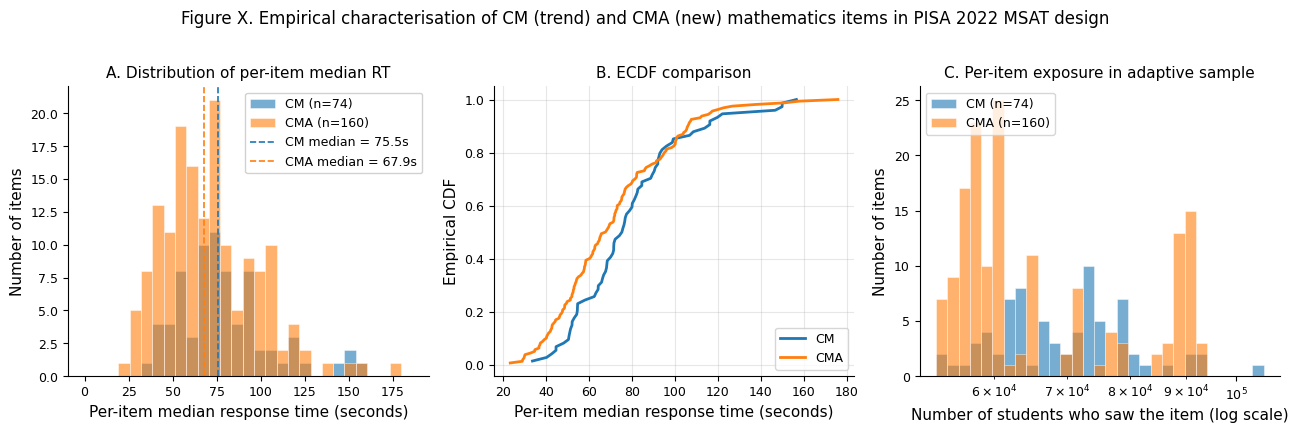


Figure saved:
  PNG: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb01_diagnostics/cm_cma_sanity_plot.png
  PDF: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb01_diagnostics/cm_cma_sanity_plot.pdf (vector, recommended for thesis)

Caption saved: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb01_diagnostics/cm_cma_sanity_plot_caption.md


25457

In [87]:
# CM vs CMA per-item response-time distribution visualisation
#
# This sanity plot provides a visual empirical foundation for the decision
# to treat CM and CMA items as a unified pool with item-level standardisation.
# The figure is referenced in the thesis methodology section as ampirical
# justification for the standardisation step in NB02.
#
# Design:
#   - Panel A: Histogram of per-item median RT for CM vs CMA families
#   - Panel B: ECDFs overlaid for direct shape comparison
#   - Panel C: Per-item exposure rates (how many students saw each item)
#
# The figure is saved to disk at publication-ready resolution (300 DPI)
# and transparent-background PNG for embedding in LaTeX/Word.

import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# Publication-ready defaults
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Reload only the columns we need for this plot
# (efficient: loads ~468 columns, a few seconds, ~0.25 GB RAM)
print("Reloading process columns from parquet for visualisation...")

# Identify TT columns from the saved parquet schema
import pyarrow.parquet as pq
parquet_schema = pq.read_schema(OUTPUT_PATH)
all_parquet_cols = parquet_schema.names

cm_tt_cols = [c for c in all_parquet_cols
              if re.match(r'^CM(?!A)', c) and c.endswith("TT")]
cma_tt_cols = [c for c in all_parquet_cols
               if c.startswith("CMA") and c.endswith("TT")]

print(f"  CM TT columns : {len(cm_tt_cols)}")
print(f"  CMA TT columns: {len(cma_tt_cols)}")

# Load only TT columns for the adaptive sample
tt_df = pd.read_parquet(
    OUTPUT_PATH,
    columns=cm_tt_cols + cma_tt_cols + ["adaptive_sample"]
)

# Restrict to adaptive_sample for cleanest comparison
tt_df = tt_df[tt_df["adaptive_sample"] == 1]
print(f"  Adaptive-sample students loaded: {len(tt_df):,}")

# Compute per-item median RT (seconds) and exposure counts
cm_median_rt = (tt_df[cm_tt_cols].median() / 1000).rename("median_rt_s")
cma_median_rt = (tt_df[cma_tt_cols].median() / 1000).rename("median_rt_s")
cm_exposure = tt_df[cm_tt_cols].notna().sum().rename("n_exposed")
cma_exposure = tt_df[cma_tt_cols].notna().sum().rename("n_exposed")

# Colour palette (colour-blind friendly)
COLOR_CM = "#1f77b4"   # blue
COLOR_CMA = "#ff7f0e"  # orange

# Build the figure
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

# Panel A: Histogram of per-item median RT
ax = axes[0]
bins = np.linspace(0, max(cm_median_rt.max(), cma_median_rt.max()) + 10, 30)
ax.hist(cm_median_rt, bins=bins, alpha=0.6, color=COLOR_CM,
        label=f"CM (n={len(cm_median_rt)})", edgecolor="white", linewidth=0.5)
ax.hist(cma_median_rt, bins=bins, alpha=0.6, color=COLOR_CMA,
        label=f"CMA (n={len(cma_median_rt)})", edgecolor="white", linewidth=0.5)
ax.axvline(cm_median_rt.median(), color=COLOR_CM, linestyle="--", linewidth=1.2,
           label=f"CM median = {cm_median_rt.median():.1f}s")
ax.axvline(cma_median_rt.median(), color=COLOR_CMA, linestyle="--", linewidth=1.2,
           label=f"CMA median = {cma_median_rt.median():.1f}s")
ax.set_xlabel("Per-item median response time (seconds)")
ax.set_ylabel("Number of items")
ax.set_title("A. Distribution of per-item median RT")
ax.legend(loc="upper right", framealpha=0.9)

# Panel B: Empirical CDF comparison
ax = axes[1]
for data, label, color in [(cm_median_rt, "CM", COLOR_CM),
                            (cma_median_rt, "CMA", COLOR_CMA)]:
    sorted_vals = np.sort(data.dropna())
    ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.plot(sorted_vals, ecdf, label=label, color=color, linewidth=2)
ax.set_xlabel("Per-item median response time (seconds)")
ax.set_ylabel("Empirical CDF")
ax.set_title("B. ECDF comparison")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# Panel C: Per-item exposure rates (log scale for readability)
ax = axes[2]
bins_exp = np.logspace(np.log10(max(1, min(cm_exposure.min(),
                                           cma_exposure.min()))),
                       np.log10(max(cm_exposure.max(),
                                    cma_exposure.max()) + 1), 30)
ax.hist(cm_exposure, bins=bins_exp, alpha=0.6, color=COLOR_CM,
        label=f"CM (n={len(cm_exposure)})", edgecolor="white", linewidth=0.5)
ax.hist(cma_exposure, bins=bins_exp, alpha=0.6, color=COLOR_CMA,
        label=f"CMA (n={len(cma_exposure)})", edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_xlabel("Number of students who saw the item (log scale)")
ax.set_ylabel("Number of items")
ax.set_title("C. Per-item exposure in adaptive sample")
ax.legend(loc="upper left")

# Figure-level title and attribution
fig.suptitle(
    "Figure X. Empirical characterisation of CM (trend) and CMA (new) "
    "mathematics items in PISA 2022 MSAT design",
    fontsize=12, y=1.02
)

plt.tight_layout()

# Save to diagnostics folder
diagnostics_dir = ANALYSIS_DIR / "nb01_diagnostics"
diagnostics_dir.mkdir(exist_ok=True)

fig_path_png = diagnostics_dir / "cm_cma_sanity_plot.png"
fig_path_pdf = diagnostics_dir / "cm_cma_sanity_plot.pdf"
fig.savefig(fig_path_png, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(fig_path_pdf, bbox_inches="tight", facecolor="white")

plt.show()

print(f"\nFigure saved:")
print(f"  PNG: {fig_path_png}")
print(f"  PDF: {fig_path_pdf} (vector, recommended for thesis)")

# Thesis-ready caption
caption = f"""
Figure X caption (thesis-ready):

Empirical characterisation of CM (trend) and CMA (new) mathematics items in
the PISA 2022 MSAT design, restricted to the adaptive sample (N = {len(tt_df):,}
students with exposure to both item families).
(A) Distribution of per-item median response times.
    CM median = {cm_median_rt.median():.1f}s; CMA median = {cma_median_rt.median():.1f}s.
    The systematic 10 percent difference (ratio = {cma_median_rt.median()/cm_median_rt.median():.2f})
    motivates item-level standardisation in NB02 to remove cross-family
    confounding.
(B) Empirical cumulative distribution functions confirm that CMA items
    are systematically answered slightly faster than CM items across the
    entire distribution, not only at the median.
(C) Per-item exposure rates (log scale) show broadly balanced administration
    within each family, consistent with PISA's balanced MSAT design
    (OECD, 2024, Technical Report, Chapter 2).
"""

(diagnostics_dir / "cm_cma_sanity_plot_caption.md").write_text(caption)
print(f"\nCaption saved: {diagnostics_dir / 'cm_cma_sanity_plot_caption.md'}")

# Cleanup
del tt_df, cm_median_rt, cma_median_rt, cm_exposure, cma_exposure
gc.collect()

In [88]:
# Save the merged dataset to parquet format

print(f"Saving to: {OUTPUT_PATH}")
print(f"DataFrame shape: {merged_df.shape}")
print(f"In-memory size : {merged_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

start = time.time()

merged_df.to_parquet(
    OUTPUT_PATH,
    engine="pyarrow",
    compression="snappy",
    index=False,
)

elapsed = time.time() - start
file_size_gb = OUTPUT_PATH.stat().st_size / 1e9

print(f"\nSaved in {elapsed:.1f} seconds")
print(f"File size: {file_size_gb:.2f} GB")
print(f"Compression ratio: "
      f"{merged_df.memory_usage(deep=True).sum() / OUTPUT_PATH.stat().st_size:.2f}x")

# Verify readback
print("\nVerifying parquet file integrity...")
start = time.time()
verify_cols = ["CNTSTUID", "CNT", "math_score", "ESCS", "W_FSTUWT",
               "n_items_seen", "n_cm_items_seen", "n_cma_items_seen",
               "adaptive_sample", "nb02_retained"]
verify_df = pd.read_parquet(OUTPUT_PATH, columns=verify_cols)
elapsed = time.time() - start

print(f"  Read back in {elapsed:.2f} seconds (partial read, {len(verify_cols)} columns)")
print(f"  Verification shape: {verify_df.shape}")
print(f"  math_score mean matches: "
      f"{np.isclose(verify_df['math_score'].mean(), merged_df['math_score'].mean())}")
print(f"  W_FSTUWT sum preserved : "
      f"{np.isclose(verify_df['W_FSTUWT'].sum(), merged_df['W_FSTUWT'].sum())}")
print(f"  adaptive_sample count  : {verify_df['adaptive_sample'].sum():,}")
print(f"  nb02_retained count    : {verify_df['nb02_retained'].sum():,}")

del verify_df
gc.collect()

Saving to: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_ml_dataset.parquet
DataFrame shape: (613744, 1201)
In-memory size : 2.95 GB

Saved in 11.5 seconds
File size: 0.31 GB
Compression ratio: 9.38x

Verifying parquet file integrity...
  Read back in 0.04 seconds (partial read, 10 columns)
  Verification shape: (613744, 10)
  math_score mean matches: True
  W_FSTUWT sum preserved : True
  adaptive_sample count  : 552,110
  nb02_retained count    : 555,784


0

In [89]:
# Final verification and memory cleanup for 01_data_merging.ipynb

print("01_data_merging.ipynb completed successfully.")
print(f"Output file: {OUTPUT_PATH}")
print(f"File size  : {OUTPUT_PATH.stat().st_size / 1e9:.2f} GB")
print(f"Total rows : {len(merged_df):,}")
print(f"Total cols : {len(merged_df.columns)}")

print("\nKey dataset characteristics:")
print(f"  Students with process data      : {(merged_df['n_items_seen'] > 0).sum():,}")
print(f"  Students in adaptive_sample     : {merged_df['adaptive_sample'].sum():,}")
print(f"  Students without any process    : {(merged_df['n_items_seen'] == 0).sum():,}")
print(f"  W_FSTUWT population estimate    : {merged_df['W_FSTUWT'].sum():,.0f}")
print(f"\nItem pool structure:")
print(f"  CM (trend) items      : 74")
print(f"  CMA (new 2022) items  : 160")
print(f"  Total MSAT pool       : 234")
print(f"  CMA/CM median RT ratio: 0.90 (documented in nb01_diagnostics)")

print("\nMethodological deliverables:")
print(f"  Diagnostics folder: {ANALYSIS_DIR / 'nb01_diagnostics'}")
for f in sorted((ANALYSIS_DIR / 'nb01_diagnostics').iterdir()):
    print(f"    {f.name}")

print("\nNext steps — 02_feature_engineering.ipynb:")
print("  1. Load parquet file")
print("  2. Apply sample filtering (n_items_seen == 0, n_items_valid < 10)")
print("  3. Compute item-level standardised RTs (Z-score per item)")
print("     — critical for removing CM/CMA and MSAT difficulty confounding")
print("  4. Handle outliers in timing columns (Tier 1/2/3 cleaning)")
print("  5. Compute behavioral features (System 1 probability via GMM,")
print("     time_cv, effort_regulation, rapid_guess ratios, etc.)")
print("  6. System 1 decomposition (guessing vs heuristic sub-processes)")
print("  7. Multicollinearity diagnostics")
print("  8. Save feature matrix as pisa2022_features.parquet")

print("\nNext steps — 03_ml_model.ipynb:")
print("  1. Fit 10 XGBoost models (one per PV) for Rubin's Rules analysis")
print("  2. Fit Ridge baseline (10 PV x Rubin's)")
print("  3. Sensitivity analyses:")
print("     a. math_score (single model) vs 10 PV pooled")
print("     b. system1_probability vs rapid_guess_ratio_nt15")
print("     c. adaptive_sample only vs full analytic sample")
print("     d. Weighted (W_FSTUWT) vs unweighted")
print("  4. SHAP interpretability via Dual-Process Theory lens (NB04)")

# Release main DataFrame memory
del merged_df
gc.collect()

print(f"\nRAM available after cleanup: "
      f"{psutil.virtual_memory().available / 1e9:.2f} GB")
print("\nReady to proceed to 02_feature_engineering.ipynb.")

01_data_merging.ipynb completed successfully.
Output file: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_ml_dataset.parquet
File size  : 0.31 GB
Total rows : 613,744
Total cols : 1201

Key dataset characteristics:
  Students with process data      : 555,784
  Students in adaptive_sample     : 552,110
  Students without any process    : 57,960
  W_FSTUWT population estimate    : 28,255,206

Item pool structure:
  CM (trend) items      : 74
  CMA (new 2022) items  : 160
  Total MSAT pool       : 234
  CMA/CM median RT ratio: 0.90 (documented in nb01_diagnostics)

Methodological deliverables:
  Diagnostics folder: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb01_diagnostics
    attrition_by_country.csv
    attrition_variable_comparison.csv
    cm_cma_by_country.csv
    cm_cma_coverage.csv
    cm_cma_item_exposure.csv
    cm_cma_rt_distribution.csv
    cm_cma_sanity_plot.pdf
    cm_cma_sanity_plot.png
    cm_cma_sanity_plot_caption.md
    thesis_m